In [20]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import norm

In [168]:
market  =  pd.read_csv("Nifty50 - Sheet1.csv")


In [171]:
# Convert Date

market['Date'] = pd.to_datetime(
    market['Date'],
    dayfirst=True
)

price_cols = ['Close', 'Open', 'High', 'Low']

for col in price_cols:

    market[col] = (
        market[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    market[col] = pd.to_numeric(
        market[col],
        errors='coerce'
    )


In [174]:
market['log_returns'] = np.log(
    market['Close'] /
    market['Close'].shift(1)
)

market = market.dropna(
    subset=['log_returns']
)

market['Month'] = market['Month'].astype(str)

market[['Month', 'Close', 'log_returns']].head()
market['Month'].nunique()


187

In [178]:
rbi = pd.read_csv(
    "repo - Sheet1.csv",
    skiprows=1
)

rbi = pd.read_csv("repo - Sheet1.csv")

rbi.columns = [
    'Month',
    'Repo Rate',
    'Regime'
]

rbi = rbi.iloc[1:].reset_index(drop=True)
rbi['Month'] = pd.to_datetime(rbi['Month'])
rbi['Repo Rate'] = pd.to_numeric(
    rbi['Repo Rate'],
    errors='coerce'
)

rbi = rbi.dropna(subset=['Repo Rate'])
rbi.columns

rbi.head()


,Month,Repo Rate,Regime
0,2010-03-01,0.0500,Tightening
1,2010-04-01,0.0525,Tightening
2,2010-05-01,0.0525,Tightening
3,2010-06-01,0.0525,Tightening
4,2010-07-01,0.0575,Tightening


In [181]:
rbi = rbi.sort_values('Month')

rbi['repo_ma12'] = (
    rbi['Repo Rate']
    .rolling(
        window=12,
        min_periods=12
    )
    .mean()
)
rbi['repo_ma12'] = (
    rbi['Repo Rate']
    .rolling(window=12, min_periods=12)
    .mean()
)
rbi[
    ['Month','Repo Rate','repo_ma12']
].head(20)

,Month,Repo Rate,repo_ma12
0,2010-03-01,0.0500,NaN
1,2010-04-01,0.0525,NaN
2,2010-05-01,0.0525,NaN
3,2010-06-01,0.0525,NaN
4,2010-07-01,0.0575,NaN
5,2010-08-01,0.0575,NaN
6,2010-09-01,0.0600,NaN
7,2010-10-01,0.0600,NaN
8,2010-11-01,0.0625,NaN
9,2010-12-01,0.0625,NaN


In [182]:
rbi['repo_gap'] = (
    rbi['Repo Rate']
    -
    rbi['repo_ma12']
)
rbi[
    [
        'Month',
        'Repo Rate',
        'repo_ma12',
        'repo_gap'
    ]
].tail(20)

,Month,Repo Rate,repo_ma12,repo_gap
170,2024-05-01,0.0650,0.065000,0.000000
171,2024-06-01,0.0650,0.065000,0.000000
172,2024-07-01,0.0650,0.065000,0.000000
173,2024-08-01,0.0650,0.065000,0.000000
174,2024-09-01,0.0650,0.065000,0.000000
175,2024-10-01,0.0650,0.065000,0.000000
176,2024-11-01,0.0650,0.065000,0.000000
177,2024-12-01,0.0650,0.065000,0.000000
178,2025-01-01,0.0650,0.065000,0.000000
179,2025-02-01,0.0625,0.064792,-0.002292


In [156]:
def classify_rolling(gap):

    if pd.isna(gap):
        return np.nan

    elif gap > 0.0025:
        return "Tightening"

    elif gap < -0.0025:
        return "Easing"

    else:
        return "Neutral"

rbi['Regime_Rolling'] = (
    rbi['repo_gap']
    .apply(classify_rolling)
) 
rbi[
    [
        'Month',
        'Repo Rate',
        'repo_gap',
        'Regime_Rolling'
    ]
].tail(30)

,Month,Repo Rate,repo_gap,Regime_Rolling
160,2023-07-01,0.0650,0.002833,Tightening
161,2023-08-01,0.0650,0.001917,Neutral
162,2023-09-01,0.0650,0.001417,Neutral
163,2023-10-01,0.0650,0.000917,Neutral
164,2023-11-01,0.0650,0.000417,Neutral
165,2023-12-01,0.0650,0.000208,Neutral
166,2024-01-01,0.0650,0.000000,Neutral
167,2024-02-01,0.0650,0.000000,Neutral
168,2024-03-01,0.0650,0.000000,Neutral
169,2024-04-01,0.0650,0.000000,Neutral


In [195]:
def classify_rolling(gap):

    if pd.isna(gap):
        return np.nan

    elif gap > 0.0025:
        return 'Tightening'

    elif gap < -0.0025:
        return 'Easing'

    else:
        return 'Neutral'


rbi['Regime_Rolling'] = (
    rbi['repo_gap']
    .apply(classify_rolling)
)

In [196]:
rbi['Regime_Rolling'].value_counts()

Regime_Rolling
Neutral       88
Easing        50
Tightening    41
Name: count, dtype: int64

In [199]:
market['Month'] = market['Month'].astype(str)
rbi['Month'] = rbi['Month'].astype(str)

market_rolling = market.merge(
    rbi[['Month', 'Regime_Rolling']],
    on='Month',
    how='left'
)

market_rolling = market_rolling.rename(
    columns={'Regime_Rolling': 'state'}
)

In [201]:
market_rolling['state'].value_counts(dropna=False)

state
Neutral       88
Easing        50
Tightening    41
NaN            8
Name: count, dtype: int64

In [202]:
policy_monthly_rolling = (
    market_rolling[['Month', 'state']]
    .drop_duplicates(subset='Month')
    .sort_values('Month')
    .reset_index(drop=True)
)

policy_monthly_rolling['state_next'] = (
    policy_monthly_rolling['state']
    .shift(-1)
)

policy_monthly_rolling = (
    policy_monthly_rolling
    .dropna(subset=['state', 'state_next'])
)

policy_monthly_rolling.head()

,Month,state,state_next
8,2011-02,Tightening,Tightening
9,2011-03,Tightening,Tightening
10,2011-04,Tightening,Tightening
11,2011-05,Tightening,Tightening
12,2011-06,Tightening,Tightening


In [203]:
transition_counts_rolling = pd.crosstab(
    policy_monthly_rolling['state'],
    policy_monthly_rolling['state_next']
)

transition_counts_rolling

state_next,Easing,Neutral,Tightening
state,,,
Easing,45,4,0
Neutral,5,80,3
Tightening,0,4,37


In [204]:
transition_matrix_rolling = (
    transition_counts_rolling.div(
        transition_counts_rolling.sum(axis=1),
        axis=0
    )
)

transition_matrix_rolling

state_next,Easing,Neutral,Tightening
state,,,
Easing,0.918367,0.081633,0.000000
Neutral,0.056818,0.909091,0.034091
Tightening,0.000000,0.097561,0.902439


In [205]:
state_stats_rolling = (
    market_rolling
    .groupby('state')['log_returns']
    .agg(['mean', 'std'])
)

state_stats_rolling

,mean,std
state,,
Easing,0.002798,0.058998
Neutral,0.013241,0.039196
Tightening,0.005859,0.045768


In [206]:
transition_matrix_rolling.sum(axis=1)

state
Easing        1.0
Neutral       1.0
Tightening    1.0
dtype: float64

In [207]:
transition_matrix_rolling

state_next,Easing,Neutral,Tightening
state,,,
Easing,0.918367,0.081633,0.000000
Neutral,0.056818,0.909091,0.034091
Tightening,0.000000,0.097561,0.902439


In [208]:
states_rolling = transition_matrix_rolling.index.tolist()

transition_probs_rolling = (
    transition_matrix_rolling.values
)

states_rolling

['Easing', 'Neutral', 'Tightening']

In [209]:
def simulate_markov_returns_rolling(
    start_state,
    transition_matrix,
    state_stats,
    n_periods=12
):

    current_state = start_state

    returns = []
    states_path = []

    for _ in range(n_periods):

        mu = state_stats.loc[
            current_state,
            'mean'
        ]

        sigma = state_stats.loc[
            current_state,
            'std'
        ]

        period_return = np.random.normal(
            mu,
            sigma
        )

        returns.append(period_return)

        states_path.append(
            current_state
        )

        current_state = np.random.choice(
            transition_matrix.columns,
            p=transition_matrix.loc[
                current_state
            ].values
        )

    return np.array(returns), states_path

In [210]:
n_sims = 1000

n_periods = 12

simulated_returns_rolling = []

start_state = (
    market_rolling['state']
    .dropna()
    .iloc[-1]
)

for _ in range(n_sims):

    sim_returns, _ = (
        simulate_markov_returns_rolling(
            start_state,
            transition_matrix_rolling,
            state_stats_rolling,
            n_periods
        )
    )

    simulated_returns_rolling.append(
        sim_returns
    )

simulated_returns_rolling = np.array(
    simulated_returns_rolling
)

simulated_returns_rolling.shape

(1000, 12)

In [211]:
last_price = market['Close'].iloc[-1]

price_paths_rolling = np.zeros(
    (n_sims, n_periods + 1)
)

price_paths_rolling[:, 0] = (
    last_price
)

for i in range(n_sims):

    cumulative_returns = np.cumsum(
        simulated_returns_rolling[i]
    )

    price_paths_rolling[i, 1:] = (
        last_price *
        np.exp(cumulative_returns)
    )

price_paths_rolling.shape

(1000, 13)

In [212]:
mean_path_rolling = (
    price_paths_rolling.mean(axis=0)
)

median_path_rolling = (
    np.median(
        price_paths_rolling,
        axis=0
    )
)

mean_path_rolling[:5]

array([25818.55      , 25915.25510034, 26058.8091513 , 26225.02584358,
       26360.83366106])

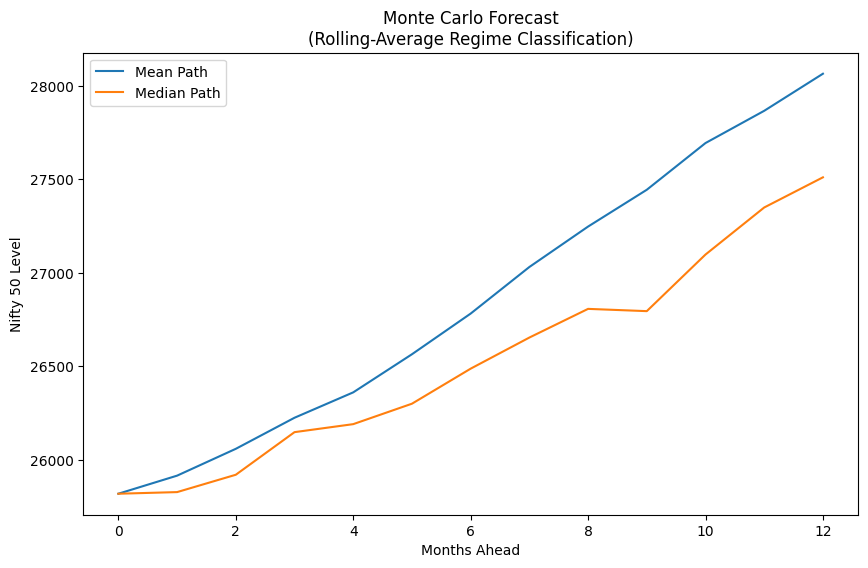

In [213]:
plt.figure(figsize=(10,6))

plt.plot(
    mean_path_rolling,
    label='Mean Path'
)

plt.plot(
    median_path_rolling,
    label='Median Path'
)

plt.title(
    'Monte Carlo Forecast\n(Rolling-Average Regime Classification)'
)

plt.xlabel('Months Ahead')

plt.ylabel('Nifty 50 Level')

plt.legend()

plt.show()

In [214]:
final_prices_rolling = (
    price_paths_rolling[:, -1]
)

print(
    "Mean Final Price:",
    final_prices_rolling.mean()
)

print(
    "Median Final Price:",
    np.median(
        final_prices_rolling
    )
)

print(
    "5th Percentile:",
    np.percentile(
        final_prices_rolling,
        5
    )
)

print(
    "95th Percentile:",
    np.percentile(
        final_prices_rolling,
        95
    )
)

Mean Final Price: 28065.554242485356
Median Final Price: 27511.245726937344
5th Percentile: 20023.829444561692
95th Percentile: 38457.23758153615


In [220]:
state_stats_rolling

,mean,std
state,,
Easing,0.002798,0.058998
Neutral,0.013241,0.039196
Tightening,0.005859,0.045768


In [221]:
final_prices_rolling.mean()

np.float64(28065.554242485356)

In [222]:
np.percentile(final_prices_rolling,[5,50,95])

array([20023.82944456, 27511.24572694, 38457.23758154])

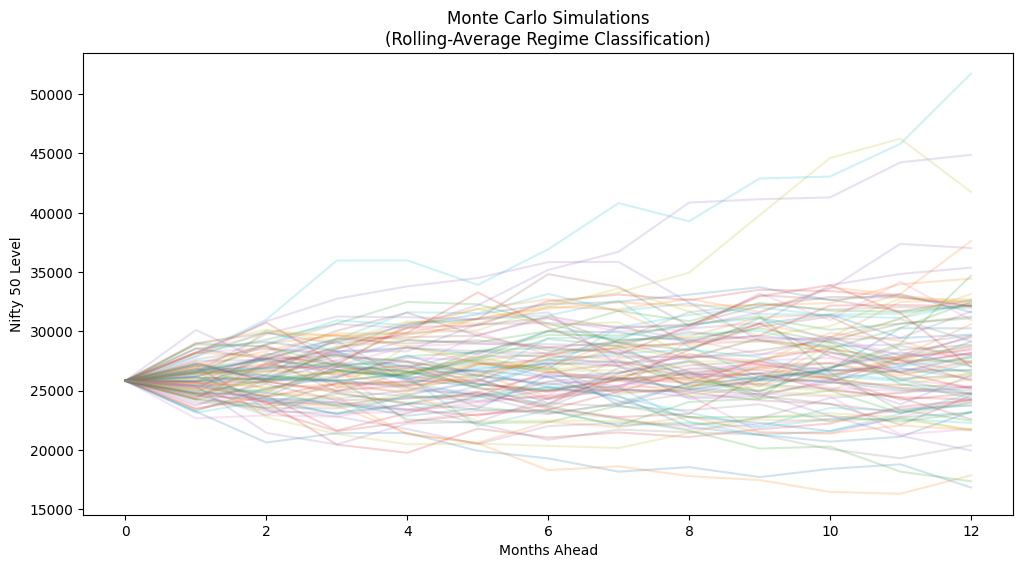

In [223]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(
        price_paths_rolling[i],
        alpha=0.2
    )

plt.title(
    'Monte Carlo Simulations\n(Rolling-Average Regime Classification)'
)

plt.xlabel('Months Ahead')
plt.ylabel('Nifty 50 Level')

plt.show()

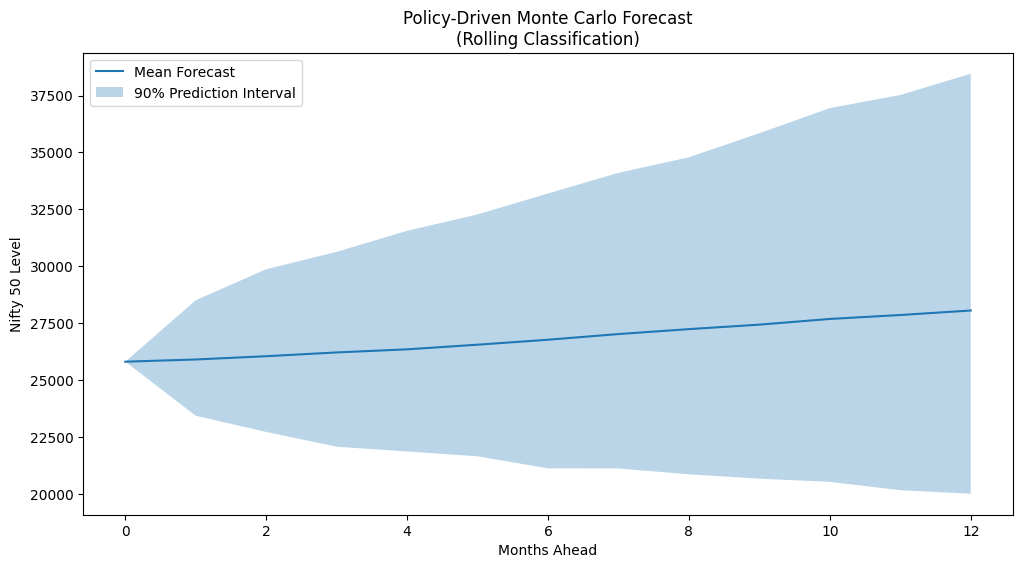

In [224]:
lower_band = np.percentile(
    price_paths_rolling,
    5,
    axis=0
)

upper_band = np.percentile(
    price_paths_rolling,
    95,
    axis=0
)

mean_path = np.mean(
    price_paths_rolling,
    axis=0
)

plt.figure(figsize=(12,6))

plt.plot(
    mean_path,
    label='Mean Forecast'
)

plt.fill_between(
    range(len(mean_path)),
    lower_band,
    upper_band,
    alpha=0.3,
    label='90% Prediction Interval'
)

plt.title(
    'Policy-Driven Monte Carlo Forecast\n(Rolling Classification)'
)

plt.xlabel('Months Ahead')
plt.ylabel('Nifty 50 Level')

plt.legend()

plt.show()

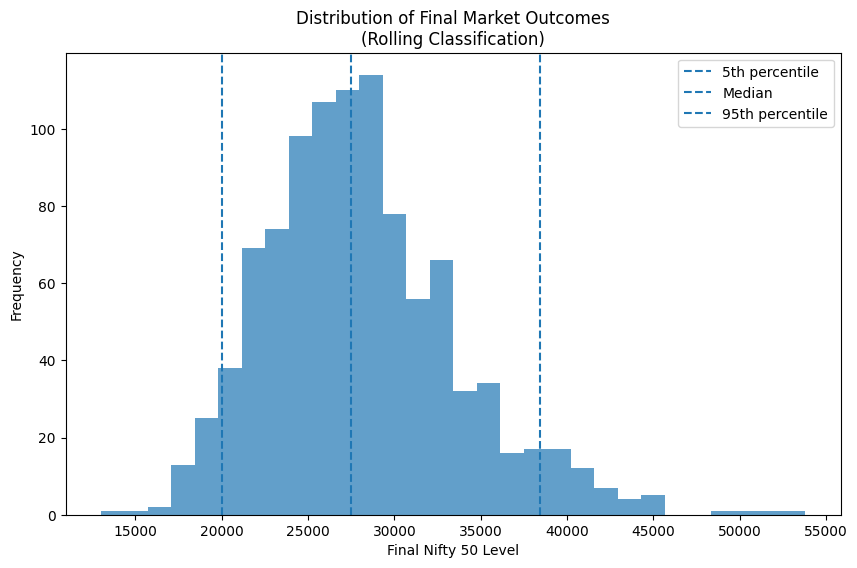

In [225]:
plt.figure(figsize=(10,6))

plt.hist(
    final_prices_rolling,
    bins=30,
    alpha=0.7
)

plt.axvline(
    np.percentile(final_prices_rolling, 5),
    linestyle='--',
    label='5th percentile'
)

plt.axvline(
    np.median(final_prices_rolling),
    linestyle='--',
    label='Median'
)

plt.axvline(
    np.percentile(final_prices_rolling, 95),
    linestyle='--',
    label='95th percentile'
)

plt.title(
    'Distribution of Final Market Outcomes\n(Rolling Classification)'
)

plt.xlabel('Final Nifty 50 Level')
plt.ylabel('Frequency')

plt.legend()

plt.show()

In [226]:
#Out of Sample Validation - Splitting the dataset inot two and running the forecast and then comapring it with the actual price at that time. 

In [227]:
market_rolling['Month'] = (
    market_rolling['Month']
    .astype(str)
)

train = market_rolling[
    market_rolling['Month'] < '2023-01'
].copy()

test = market_rolling[
    market_rolling['Month'] >= '2023-01'
].copy()

print(len(train))
print(len(test))

151
36


In [229]:
train_states = (
    train[['Month','state']]
    .drop_duplicates()
    .sort_values('Month')
)

train_states['state_next'] = (
    train_states['state']
    .shift(-1)
)

train_states = train_states.dropna()

transition_counts_train = pd.crosstab(
    train_states['state'],
    train_states['state_next']
)

transition_matrix_train = (
    transition_counts_train.div(
        transition_counts_train.sum(axis=1),
        axis=0
    )
)

transition_matrix_train

state_next,Easing,Neutral,Tightening
state,,,
Easing,0.902439,0.097561,0.000000
Neutral,0.058824,0.897059,0.044118
Tightening,0.000000,0.090909,0.909091


In [230]:
state_stats_train = (
    train.groupby('state')['log_returns']
    .agg(['mean','std'])
)

state_stats_train

,mean,std
state,,
Easing,0.001137,0.064201
Neutral,0.014569,0.039653
Tightening,0.004502,0.048982


In [231]:
start_state = (
    train_states['state']
    .iloc[-1]
)

start_state

'Tightening'

In [232]:
start_price = (
    train['Close']
    .iloc[-1]
)

start_price

np.float64(18105.3)

In [233]:
forecast_horizon = (
    test['Month']
    .nunique()
)

forecast_horizon

36

In [234]:
n_sims = 1000

validation_returns = []

for _ in range(n_sims):

    sim_returns, _ = simulate_markov_returns(
        start_state,
        transition_matrix_train,
        state_stats_train,
        forecast_horizon
    )

    validation_returns.append(
        sim_returns
    )

validation_returns = np.array(
    validation_returns
)

In [235]:
validation_paths = np.zeros(
    (n_sims, forecast_horizon + 1)
)

validation_paths[:,0] = start_price

for i in range(n_sims):

    cumulative_returns = np.cumsum(
        validation_returns[i]
    )

    validation_paths[i,1:] = (
        start_price *
        np.exp(cumulative_returns)
    )

In [236]:
actual_prices = (
    test
    .groupby('Month')
    .last()['Close']
    .values
)

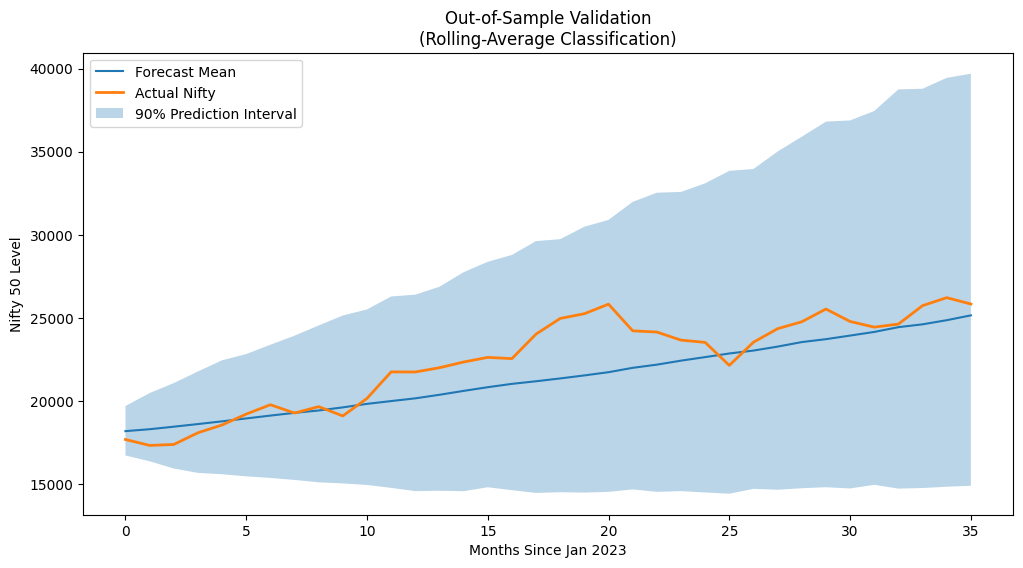

In [237]:
mean_forecast = (
    validation_paths.mean(axis=0)
)

lower_band = np.percentile(
    validation_paths,
    5,
    axis=0
)

upper_band = np.percentile(
    validation_paths,
    95,
    axis=0
)

plt.figure(figsize=(12,6))

plt.plot(
    mean_forecast[1:],
    label='Forecast Mean'
)

plt.plot(
    actual_prices,
    linewidth=2,
    label='Actual Nifty'
)

plt.fill_between(
    range(len(actual_prices)),
    lower_band[1:],
    upper_band[1:],
    alpha=0.3,
    label='90% Prediction Interval'
)

plt.title(
    'Out-of-Sample Validation\n(Rolling-Average Classification)'
)

plt.xlabel('Months Since Jan 2023')
plt.ylabel('Nifty 50 Level')

plt.legend()

plt.show()

In [238]:
transition_matrix_train

state_next,Easing,Neutral,Tightening
state,,,
Easing,0.902439,0.097561,0.000000
Neutral,0.058824,0.897059,0.044118
Tightening,0.000000,0.090909,0.909091


In [239]:
state_stats_train

,mean,std
state,,
Easing,0.001137,0.064201
Neutral,0.014569,0.039653
Tightening,0.004502,0.048982


In [240]:
actual_final = actual_prices[-1]

forecast_median = np.median(
    validation_paths[:, -1]
)

forecast_mean = np.mean(
    validation_paths[:, -1]
)

print("Actual Final Value:", actual_final)
print("Forecast Median:", forecast_median)
print("Forecast Mean:", forecast_mean)

Actual Final Value: 25818.55
Forecast Median: 23966.12914655042
Forecast Mean: 25136.548353215276


In [242]:
forecast_error = (
    actual_final -
    forecast_mean
)

percent_error = (
    forecast_error /
    actual_final
) * 100

print(percent_error) # A 2.6% error percentage over 3 years is pretty strong

2.6415180046312576


In [243]:
#Likelihood Ratio Test: Transition probabilities have been assumed to stay constant regardless of economic state. To tackle this, we take two models: one that uses a matrice for the entire smaple and one that divides it into different subperiods. Then we compare.

In [244]:
states_lr = (
    market_rolling[['Month','state']]
    .drop_duplicates()
    .sort_values('Month')
)

states_lr.head()

,Month,state
0,2010-06,NaN
1,2010-07,NaN
2,2010-08,NaN
3,2010-09,NaN
4,2010-10,NaN


In [245]:
period1 = states_lr[
    states_lr['Month'] < '2018-01'
].copy()

period2 = states_lr[
    states_lr['Month'] >= '2018-01'
].copy()

print(len(period1))
print(len(period2))

91
96


In [246]:
period1['state_next'] = (
    period1['state']
    .shift(-1)
)

period1_mc = period1.dropna()

counts1 = pd.crosstab(
    period1_mc['state'],
    period1_mc['state_next']
)

counts1

state_next,Easing,Neutral,Tightening
state,,,
Easing,17,3,0
Neutral,3,38,1
Tightening,0,2,18


In [247]:
period2['state_next'] = (
    period2['state']
    .shift(-1)
)

period2_mc = period2.dropna()

counts2 = pd.crosstab(
    period2_mc['state'],
    period2_mc['state_next']
)

counts2

state_next,Easing,Neutral,Tightening
state,,,
Easing,28,1,0
Neutral,2,41,2
Tightening,0,2,19


In [248]:
states_full = (
    market_rolling[['Month','state']]
    .drop_duplicates()
    .sort_values('Month')
)

states_full['state_next'] = (
    states_full['state']
    .shift(-1)
)

states_full = states_full.dropna()

counts_full = pd.crosstab(
    states_full['state'],
    states_full['state_next']
)

counts_full

state_next,Easing,Neutral,Tightening
state,,,
Easing,45,4,0
Neutral,5,80,3
Tightening,0,4,37


In [249]:
P1 = counts1.div(
    counts1.sum(axis=1),
    axis=0
)

P2 = counts2.div(
    counts2.sum(axis=1),
    axis=0
)

P_full = counts_full.div(
    counts_full.sum(axis=1),
    axis=0
)

In [250]:
import numpy as np

def log_likelihood(counts, probs):

    ll = 0

    for i in counts.index:
        for j in counts.columns:

            nij = counts.loc[i,j]

            pij = probs.loc[i,j]

            if nij > 0 and pij > 0:
                ll += nij * np.log(pij)

    return ll

In [251]:
LL_restricted = log_likelihood(
    counts_full,
    P_full
)

LL_restricted

np.float64(-59.06200211783431)

In [252]:
LL_unrestricted = (
    log_likelihood(counts1, P1)
    +
    log_likelihood(counts2, P2)
)

LL_unrestricted

np.float64(-57.63881185040291)

In [253]:
LR = 2 * (
    LL_unrestricted
    -
    LL_restricted
)

LR

np.float64(2.846380534862803)

In [257]:
#states = 3

#free parameters per matrix

#= 3 × (3 − 1) = 6

df = 6

In [258]:
from scipy.stats import chi2

p_value = 1 - chi2.cdf(
    LR,
    df
)

print("LR Statistic:", LR)
print("p-value:", p_value)

LR Statistic: 2.846380534862803
p-value: 0.8278660316346873


In [259]:
counts1

state_next,Easing,Neutral,Tightening
state,,,
Easing,17,3,0
Neutral,3,38,1
Tightening,0,2,18


In [260]:
counts2

state_next,Easing,Neutral,Tightening
state,,,
Easing,28,1,0
Neutral,2,41,2
Tightening,0,2,19


In [263]:
#We fail to reject the null hypothesis. This means there is no statistical evidence 
#that the transition dynamics changed between 2010–2017 and 2018–2025.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [264]:
#Random Walk Benchmark Test: See if the MonteCarlo actually outperfoms a random walk.

In [265]:
mu_rw = train['log_returns'].mean()

sigma_rw = train['log_returns'].std()

print(mu_rw)
print(sigma_rw)

0.008408305048860917
0.05049355072113096


In [266]:
n_sims = 1000
forecast_horizon
start_price

np.float64(18105.3)

In [267]:
rw_paths = np.zeros(
    (n_sims, forecast_horizon + 1)
)

rw_paths[:,0] = start_price

for i in range(n_sims):

    random_returns = np.random.normal(
        mu_rw,
        sigma_rw,
        forecast_horizon
    )

    cumulative_returns = np.cumsum(
        random_returns
    )

    rw_paths[i,1:] = (
        start_price *
        np.exp(cumulative_returns)
    )

In [268]:
rw_mean = rw_paths.mean(axis=0)

rw_lower = np.percentile(
    rw_paths,
    5,
    axis=0
)

rw_upper = np.percentile(
    rw_paths,
    95,
    axis=0
)

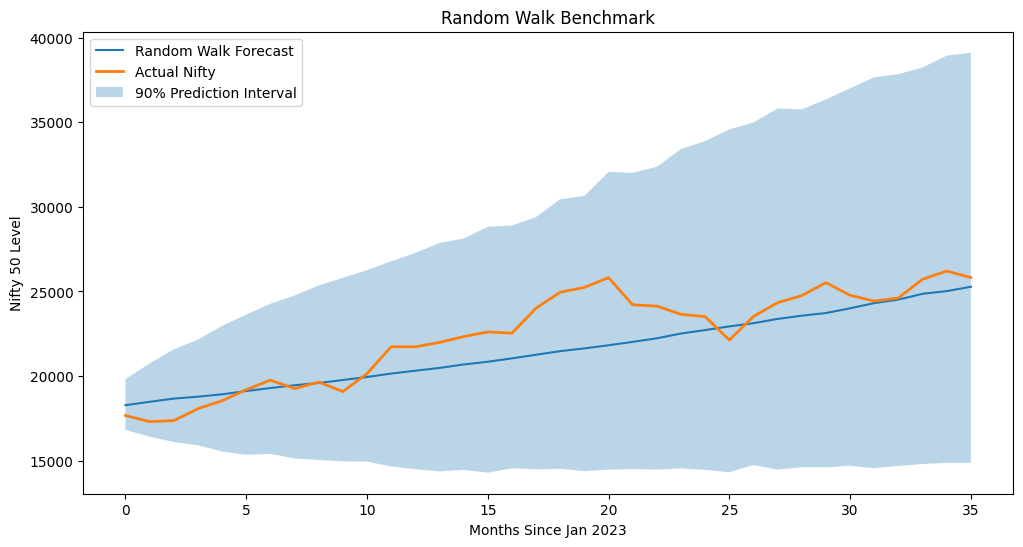

In [269]:
plt.figure(figsize=(12,6))

plt.plot(
    rw_mean[1:],
    label='Random Walk Forecast'
)

plt.plot(
    actual_prices,
    linewidth=2,
    label='Actual Nifty'
)

plt.fill_between(
    range(len(actual_prices)),
    rw_lower[1:],
    rw_upper[1:],
    alpha=0.3,
    label='90% Prediction Interval'
)

plt.title(
    'Random Walk Benchmark'
)

plt.xlabel('Months Since Jan 2023')
plt.ylabel('Nifty 50 Level')

plt.legend()

plt.show()

In [270]:
rw_forecast_mean = np.mean(
    rw_paths[:, -1]
)

rw_error = (
    actual_final -
    rw_forecast_mean
)

rw_percent_error = (
    rw_error /
    actual_final
) * 100

print(
    "Random Walk Forecast Error:",
    rw_percent_error
)

Random Walk Forecast Error: 2.1144059921043863


In [271]:
print("Markov Model Error:", 2.64)
print("Random Walk Error:", rw_percent_error)

Markov Model Error: 2.64
Random Walk Error: 2.1144059921043863


In [275]:
#ANOVA Test: The ANOVA asks: Are the average returns in Easing, Neutral, and Tightening regimes genuinely different, or could the observed differences have arisen by chance?

In [276]:
from scipy.stats import f_oneway

easing_returns = market_rolling.loc[
    market_rolling['state'] == 'Easing',
    'log_returns'
]

neutral_returns = market_rolling.loc[
    market_rolling['state'] == 'Neutral',
    'log_returns'
]

tightening_returns = market_rolling.loc[
    market_rolling['state'] == 'Tightening',
    'log_returns'
]

In [277]:
f_stat, p_value = f_oneway(
    easing_returns,
    neutral_returns,
    tightening_returns
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.8813895080460893
p-value: 0.4160271090470249


In [278]:
from scipy.stats import kruskal

h_stat, p_value_kw = kruskal(
    easing_returns,
    neutral_returns,
    tightening_returns
)

print("H-statistic:", h_stat)
print("p-value:", p_value_kw)

H-statistic: 1.7539317180525131
p-value: 0.4160433326896815
